In [1]:
import os
import splitfolders
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Using relative path since notebook is in 'AI project' folder
DATA_DIR = 'dataset/Dataset for skin cancer/organized_data'

if os.path.exists(DATA_DIR):
    classes = os.listdir(DATA_DIR)
    print(f"✅ Libraries Ready. Detected Classes: {classes}")
    
    # Check distribution (Crucial for medical AI accuracy)
    stats = []
    for c in classes:
        count = len(os.listdir(os.path.join(DATA_DIR, c)))
        stats.append({'Class': c, 'Count': count})
    
    df_stats = pd.DataFrame(stats)
    print("\n--- Image Distribution ---")
    print(df_stats)
else:
    print("❌ Path error. Ensure your notebook is inside 'AI project'.")
    print(f"Current location of notebook: {os.getcwd()}")

✅ Libraries Ready. Detected Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

--- Image Distribution ---
   Class  Count
0  akiec    328
1    bcc    514
2    bkl   1099
3     df    115
4    mel   1113
5     nv   1500
6   vasc    142


✅ Verified 7 classes in order: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


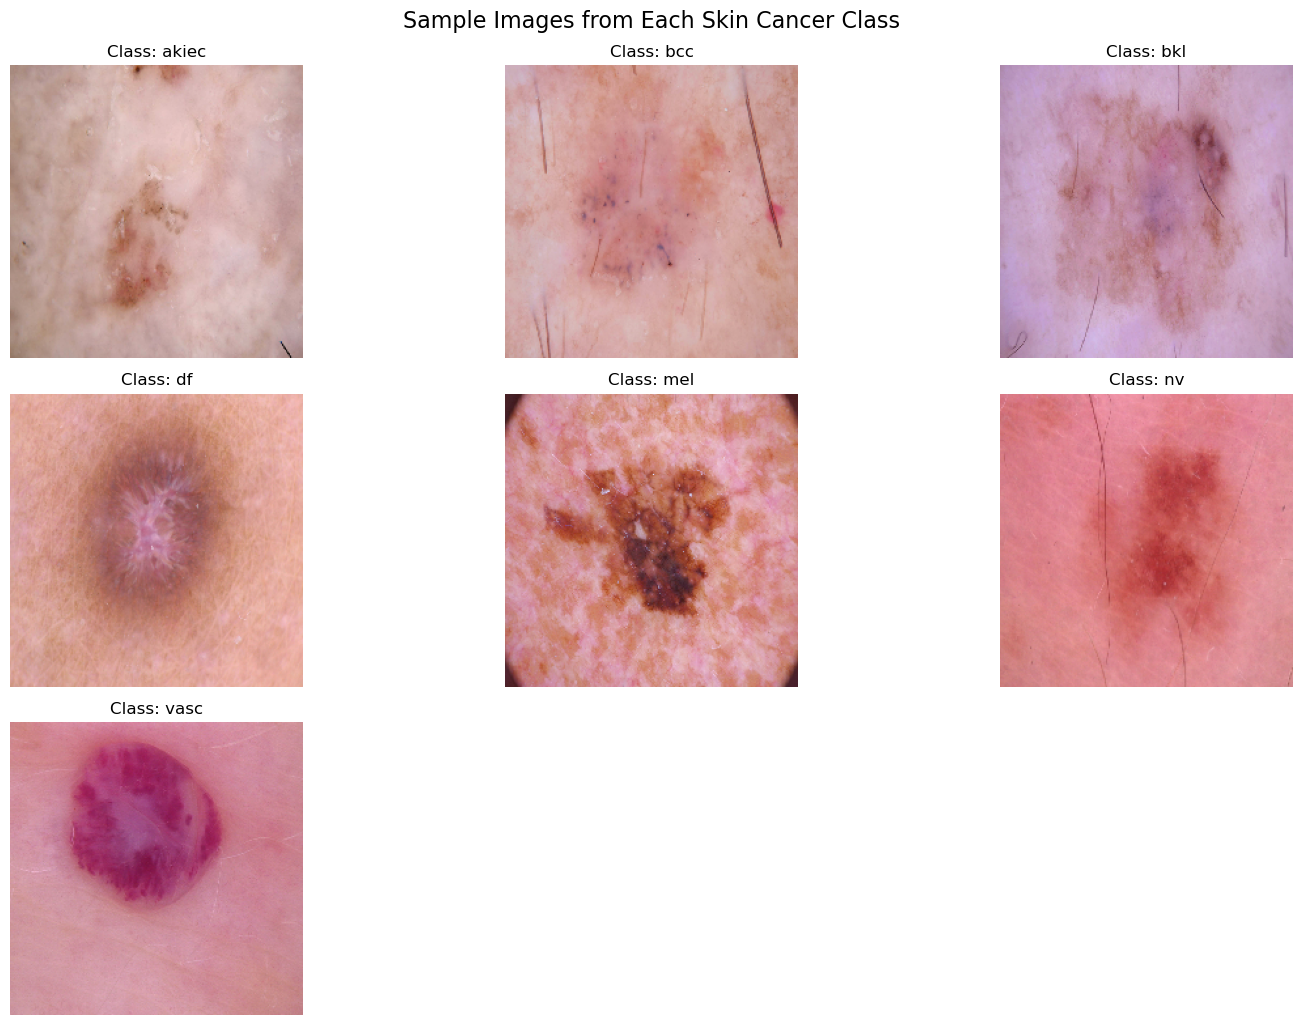

In [ ]:
import os
import matplotlib.pyplot as plt
import tensorflow as tf



if os.path.exists(DATA_DIR):
    # Filter to ensure we only look at directories
    classes = sorted([c for c in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, c))])
    print(f"✅ Verified {len(classes)} classes in order: {classes}")
    

    plt.figure(figsize=(15, 10))

    for i, label in enumerate(classes):
        class_path = os.path.join(DATA_DIR, label)
        
        # Get all images in the folder
        img_names = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        if len(img_names) > 0:
            img_path = os.path.join(class_path, img_names[0])
            
            # Load and display
            img = tf.keras.utils.load_img(img_path, target_size=(224, 224))
            plt.subplot(3, 3, i + 1)
            plt.imshow(img)
            plt.title(f"Class: {label}")
            plt.axis('off')

    plt.tight_layout()
    plt.suptitle("Sample Images from Each Skin Cancer Class", fontsize=16, y=1.02)
    plt.show()
else:
    print(f"❌ DATA_DIR not found at {DATA_DIR}")

C:\Users\Tesfaye\AppData\Local\Temp\ipykernel_10068\1851057129.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_stats, x='Class', y='Count', palette='viridis')


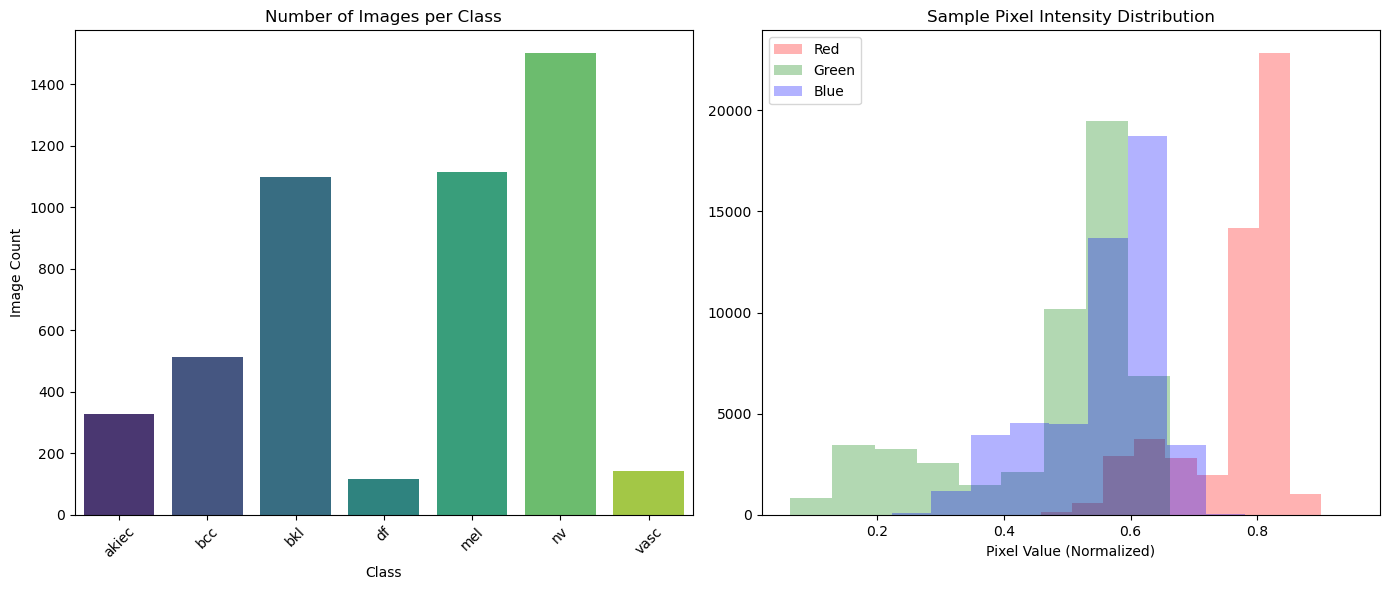

In [3]:
import seaborn as sns
import numpy as np
import pandas as pd

# Re-calculate stats to ensure df_stats is fresh
stats = []
for c in classes:
    count = len(os.listdir(os.path.join(DATA_DIR, c)))
    stats.append({'Class': c, 'Count': count})
df_stats = pd.DataFrame(stats)

plt.figure(figsize=(14, 6))

# Bar Chart for Class Distribution
plt.subplot(1, 2, 1)
sns.barplot(data=df_stats, x='Class', y='Count', palette='viridis')
plt.title("Number of Images per Class")
plt.xticks(rotation=45)
plt.ylabel("Image Count")

# Pixel Intensity Check (Using the 'img' from the previous cell)
plt.subplot(1, 2, 2)
sample_array = np.array(img) / 255.0 
plt.hist(sample_array[:, :, 0].flatten(), color='red', alpha=0.3, label='Red')
plt.hist(sample_array[:, :, 1].flatten(), color='green', alpha=0.3, label='Green')
plt.hist(sample_array[:, :, 2].flatten(), color='blue', alpha=0.3, label='Blue')
plt.title("Sample Pixel Intensity Distribution")
plt.xlabel("Pixel Value (Normalized)")
plt.legend()

plt.tight_layout()
plt.show()

In [4]:
# 1. Define Augmentation Logic
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

# 2. Connect to the NEW PHYSICAL FOLDERS
train_generator = train_datagen.flow_from_directory(
    'dataset_final/train',
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical'
)

validation_generator = val_datagen.flow_from_directory(
    'dataset_final/test',
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical'
)

Found 3846 images belonging to 7 classes.
Found 487 images belonging to 7 classes.


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam


base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False 

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(), 
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5), 
    layers.Dense(7, activation='softmax') # Using 7 for your cancer classes
])


model.compile(
    optimizer=Adam(learning_rate=0.0001), 
    loss='categorical_crossentropy', 
    metrics=['accuracy']
)

print("✅ Model Architecture Fixed and Compiled.")
model.summary()

✅ Model Architecture Fixed and Compiled.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)                │ (None, 7, 7, 2048)          │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 2048)                │           8,192 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         524,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 7)                   │           1,799 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 24,122,247 (92.02 MB)

 Trainable params: 530,439 (2.02 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


base_model.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5), 
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


early_stop = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)

print("--- Phase 2: Fine-Tuning Entire Model ---")
history = model.fit(
    train_generator, 
    validation_data=validation_generator, 
    epochs=50, # Increased epochs because EarlyStopping will handle the cutoff
    callbacks=[early_stop]
)

--- Phase 2: Fine-Tuning Entire Model ---
Epoch 1/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 920s 4s/step - accuracy: 0.2943 - loss: 2.2506 - val_accuracy: 0.3101 - val_loss: 11.5267
Epoch 2/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 911s 4s/step - accuracy: 0.4519 - loss: 1.6760 - val_accuracy: 0.2546 - val_loss: 12.9459
Epoch 3/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 1079s 4s/step - accuracy: 0.4971 - loss: 1.4876 - val_accuracy: 0.3573 - val_loss: 4.0768
Epoch 4/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 1044s 4s/step - accuracy: 0.5439 - loss: 1.3460 - val_accuracy: 0.4333 - val_loss: 2.1805
Epoch 5/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 889s 4s/step - accuracy: 0.5918 - loss: 1.1986 - val_accuracy: 0.6345 - val_loss: 1.1889
Epoch 6/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 903s 4s/step - accuracy: 0.6178 - loss: 1.1302 - val_accuracy: 0.7043 - val_loss: 0.8732
Epoch 7/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 881s 4s/step - accuracy: 0.6378 - loss: 1.0306 - val_accuracy: 0.7043 - val_loss: 0.8684
Epoch 8/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 884s 4s/ste

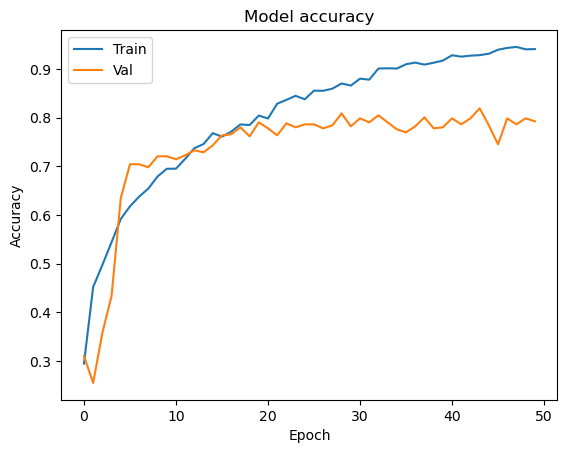

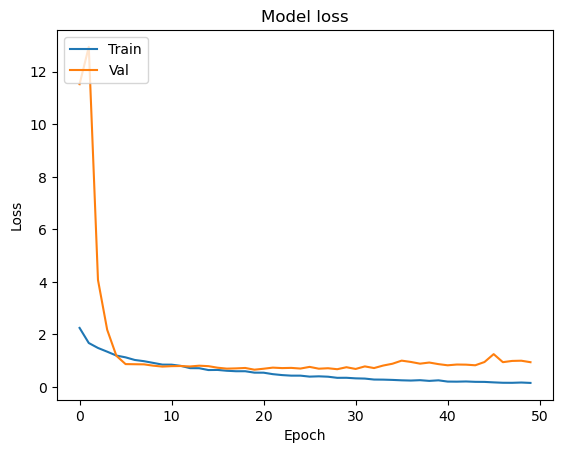

In [7]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

In [8]:
# 1. Create a generator for the hidden 'test' folder
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    'dataset_final/test',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False # Crucial for the confusion matrix!
)

# 2. Evaluate the model
test_loss, test_acc = model.evaluate(test_generator)
print(f"Final Test Accuracy: {test_acc*100:.2f}%")

# 3. Save your hard work!
model.save('1234skin_cancer_model_final.h5')
print("✅ Model saved as skin_cancer_model_final.h5")

Found 487 images belonging to 7 classes.
16/16 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step - accuracy: 0.7906 - loss: 0.6607


Final Test Accuracy: 79.06%
✅ Model saved as skin_cancer_model_final.h5


In [9]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Get the true labels and the model's predictions
Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)

print('--- Classification Report ---')
target_names = list(test_generator.class_indices.keys())
print(classification_report(test_generator.classes, y_pred, target_names=target_names))

16/16 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step
--- Classification Report ---
              precision    recall  f1-score   support

       akiec       0.87      0.57      0.69        35
         bcc       0.85      0.87      0.86        52
         bkl       0.72      0.79      0.76       111
          df       0.75      0.50      0.60        12
         mel       0.74      0.80      0.77       112
          nv       0.84      0.82      0.83       150
        vasc       1.00      0.87      0.93        15

    accuracy                           0.79       487
   macro avg       0.82      0.75      0.78       487
weighted avg       0.80      0.79      0.79       487



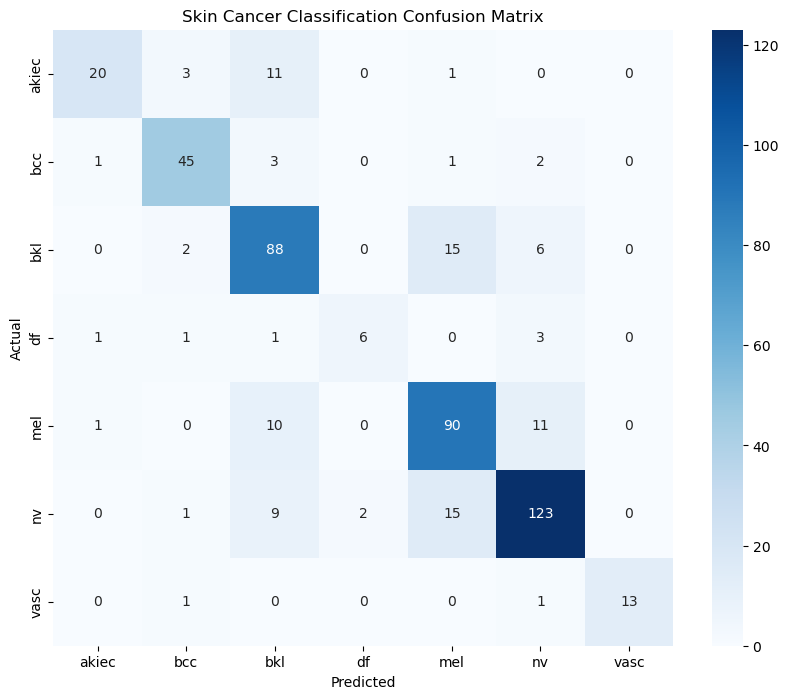

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(test_generator.classes, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Skin Cancer Classification Confusion Matrix')
plt.show()